In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
cols = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state",
    "party",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

In [12]:
df_1 = pd.read_csv("../data/LIAR/train.tsv", sep="\t", names=cols)
df_1.shape

(10240, 14)

In [13]:
df_2 = pd.read_csv("../data/LIAR/valid.tsv", sep="\t", names=cols)
df_2.shape

(1284, 14)

In [14]:
df_3 = pd.read_csv("../data/LIAR/test.tsv", sep="\t", names=cols)
df_3.shape

(1267, 14)

In [17]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)
df.shape

(12791, 14)

In [18]:
df.head()

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    12791 non-null  object 
 1   label                 12791 non-null  object 
 2   statement             12791 non-null  object 
 3   subject               12789 non-null  object 
 4   speaker               12789 non-null  object 
 5   speaker_job           9223 non-null   object 
 6   state                 10040 non-null  object 
 7   party                 12789 non-null  object 
 8   barely_true_counts    12789 non-null  float64
 9   false_counts          12789 non-null  float64
 10  half_true_counts      12789 non-null  float64
 11  mostly_true_counts    12789 non-null  float64
 12  pants_on_fire_counts  12789 non-null  float64
 13  context               12660 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.4+ MB


In [21]:
df.sample(5)

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
6006,10418.json,mostly-true,A strong majority of Americans support the Key...,"energy,environment,infrastructure",joni-ernst,U.S. senator,Iowa,republican,2.0,1.0,1.0,1.0,0.0,the Republican response to the State of the Un...
11854,6560.json,true,If you look at the number of illegal immigrant...,immigration,jeb-bush,NaN,Florida,republican,17.0,5.0,17.0,24.0,2.0,an interview on 'Meet the Press.'
6434,3269.json,half-true,The federal government regulates the holes in ...,"food-safety,government-efficiency",lynn-westmoreland,NaN,NaN,republican,1.0,1.0,3.0,0.0,0.0,NaN
2025,8918.json,false,On repealing the 17th Amendment,"debates,elections,states",dan-patrick,Lieutenant governor-elect,Texas,republican,4.0,4.0,3.0,4.0,4.0,a debate
3794,3835.json,pants-fire,House Republicans required the use of Styrofoa...,congressional-rules,jim-moran,U. S. Congressman,Virginia,democrat,2.0,1.0,1.0,6.0,1.0,a speech.


In [58]:
df["state"].unique().tolist()

['Texas',
 'Virginia',
 'Illinois',
 nan,
 'Florida',
 'Wisconsin',
 'New Jersey',
 'Vermont',
 'Massachusetts',
 'Maryland',
 'Washington, D.C. ',
 'Oregon',
 'New York',
 'Washington, D.C.',
 'California',
 'Missouri',
 'Rhode Island',
 'West Virginia',
 'Arkansas',
 'New Hampshire',
 'Ohio',
 'Georgia',
 'Arizona',
 'Wyoming',
 'Delaware',
 'Kentucky',
 'Kansas',
 'ohio',
 'Colorado',
 'North Carolina',
 'New Mexico',
 'Illinois ',
 'Alaska',
 'South Carolina',
 'Minnesota',
 'Tennessee',
 'Pennsylvania',
 'Iowa',
 'Connecticut',
 'Louisiana',
 'Indiana',
 'Florida ',
 'Utah',
 'Michigan',
 'Oklahoma',
 'Nevada',
 'Oregon ',
 'Virgina',
 'Nebraska',
 'Georgia ',
 'Washington D.C.',
 'California ',
 'Massachusetts ',
 'Alabama',
 'Russia',
 'Washington state',
 'Washington',
 'District of Columbia',
 'Unknown',
 'Colorado ',
 'New Hampshire ',
 'Mississippi',
 'Rhode island',
 'China',
 'United Kingdom',
 'Virginia ',
 'South Dakota',
 'Qatar',
 'Montana',
 'North Dakota',
 'Idaho',


In [61]:
df["state"] = df["state"].astype(str).str.strip()

df["state"] = df["state"].str.title()

df["state"] = df["state"].replace({
    "Washington, D.C.": "District Of Columbia",
    "Washington D.C.": "District Of Columbia",
    "Washington Dc": "District Of Columbia",
    "Washington Dc.": "District Of Columbia",
    "Washington Dc ": "District Of Columbia"
})


In [62]:
df["state"].unique().tolist()

['Texas',
 'Virginia',
 'Illinois',
 'Nan',
 'Florida',
 'Wisconsin',
 'New Jersey',
 'Vermont',
 'Massachusetts',
 'Maryland',
 'District Of Columbia',
 'Oregon',
 'New York',
 'California',
 'Missouri',
 'Rhode Island',
 'West Virginia',
 'Arkansas',
 'New Hampshire',
 'Ohio',
 'Georgia',
 'Arizona',
 'Wyoming',
 'Delaware',
 'Kentucky',
 'Kansas',
 'Colorado',
 'North Carolina',
 'New Mexico',
 'Alaska',
 'South Carolina',
 'Minnesota',
 'Tennessee',
 'Pennsylvania',
 'Iowa',
 'Connecticut',
 'Louisiana',
 'Indiana',
 'Utah',
 'Michigan',
 'Oklahoma',
 'Nevada',
 'Virgina',
 'Nebraska',
 'Alabama',
 'Russia',
 'Washington State',
 'Washington',
 'Unknown',
 'Mississippi',
 'China',
 'United Kingdom',
 'South Dakota',
 'Qatar',
 'Montana',
 'North Dakota',
 'Idaho',
 'Maine',
 'Virginia Director, Coalition To Stop Gun Violence',
 'Virgiia',
 'Hawaii',
 'Atlanta',
 'Tennesse',
 'Pa - Pennsylvania',
 'Tex',
 'The United States']

The `state` field contains heterogeneous entries including U.S. states, international locations, cities, and free-text descriptors, indicating limited schema enforcement in the original dataset.

In [63]:
sorted(df["party"].astype(str).str.strip().unique())

['Moderate',
 'activist',
 'business-leader',
 'columnist',
 'constitution-party',
 'county-commissioner',
 'democrat',
 'democratic-farmer-labor',
 'education-official',
 'government-body',
 'green',
 'independent',
 'journalist',
 'labor-leader',
 'liberal-party-canada',
 'libertarian',
 'nan',
 'newsmaker',
 'none',
 'ocean-state-tea-party-action',
 'organization',
 'republican',
 'state-official',
 'talk-show-host',
 'tea-party-member']

In [64]:
df["party"] = df["party"].fillna("unknown")
df["party"] = df["party"].astype(str).str.strip().str.lower()

In [65]:
def simplify_party(p):
    if p == "democrat" or p == "democratic-farmer-labor":
        return "democrat"
    elif p == "republican":
        return "republican"
    elif p in ["independent", "libertarian", "green", "constitution-party"]:
        return "third-party"
    elif p in ["none", "unknown", "nan"]:
        return "unknown"
    else:
        return "non-party-role"

df["party_grouped"] = df["party"].apply(simplify_party)

In [66]:
df["party_grouped"].value_counts(normalize=True)

party_grouped
republican        0.442890
democrat          0.323509
unknown           0.170667
non-party-role    0.044406
third-party       0.018529
Name: proportion, dtype: float64

The `party` field includes heterogeneous entity types including political parties, occupations, organizations, and media sources. For analytical clarity, we created a simplified grouping distinguishing major parties, third parties, non-party roles, and unknown categories.

In [57]:
df["speaker"].unique()


array(['dwayne-bohac', 'scott-surovell', 'barack-obama', ...,
       'hugh-fitzsimons', 'menendez-facts', 'mackubin-thomas-owens'],
      shape=(3310,), dtype=object)

In [39]:
print(df.shape)
print("\nColumns:")
print(df.columns)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel proportions:")
print(df["label"].value_counts(normalize=True))


(12791, 16)

Columns:
Index(['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
       'state', 'party', 'barely_true_counts', 'false_counts',
       'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts',
       'context', 'statement_length', 'total_prior_statements'],
      dtype='object')

Label distribution:
label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64

Label proportions:
label
half-true      0.205379
false          0.195997
mostly-true    0.191854
barely-true    0.164412
true           0.160503
pants-fire     0.081854
Name: proportion, dtype: float64


In [40]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique speakers:", df["speaker"].nunique())
print("Unique parties:", df["party"].nunique())
print("Unique states:", df["state"].nunique())


Missing values per column:
id                           0
label                        0
statement                    0
subject                      2
speaker                      2
speaker_job               3568
state                     2751
party                        2
barely_true_counts           2
false_counts                 2
half_true_counts             2
mostly_true_counts           2
pants_on_fire_counts         2
context                    131
statement_length             0
total_prior_statements       0
dtype: int64

Unique speakers: 3309
Unique parties: 24
Unique states: 84


In [41]:
party_label = pd.crosstab(df["party"], df["label"])
print(party_label)

print("\nParty distribution:")
print(df["party"].value_counts())

print("\nParty vs label (row-normalized):")
print(pd.crosstab(df["party"], df["label"], normalize="index"))

label                         barely-true  false  half-true  mostly-true  \
party                                                                      
Moderate                                0      1          0            0   
activist                                7      9         11           13   
business-leader                         0      1          0            2   
columnist                               9     11          4            7   
constitution-party                      0      2          0            0   
county-commissioner                     0      1          1            0   
democrat                              586    633        931          995   
democratic-farmer-labor                 0      0          1            0   
education-official                      0      0          0            3   
government-body                         0      0          1            1   
green                                   0      1          0            0   
independent 

In [42]:
major = df[df["party"].isin(["democrat","republican"])]

print("Counts:")
print(major["party"].value_counts())

print("\nNormalized truth distribution by party:")
print(pd.crosstab(
    major["party"],
    major["label"],
    normalize="index"
))


Counts:
party
republican    5665
democrat      4137
Name: count, dtype: int64

Normalized truth distribution by party:
label       barely-true     false  half-true  mostly-true  pants-fire  \
party                                                                   
democrat       0.141649  0.153009   0.225042     0.240512    0.044718   
republican     0.187290  0.229303   0.200000     0.159400    0.081377   

label           true  
party                 
democrat    0.195069  
republican  0.142630  


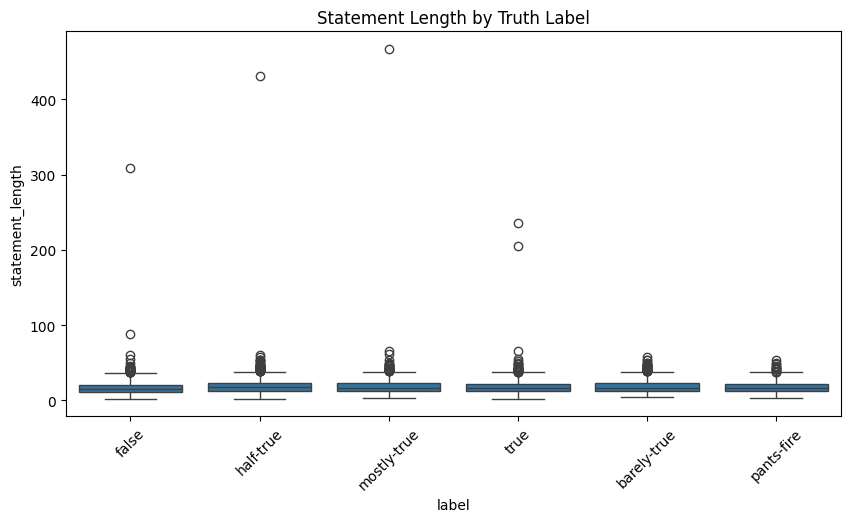

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="statement_length")
plt.xticks(rotation=45)
plt.title("Statement Length by Truth Label")
plt.show()

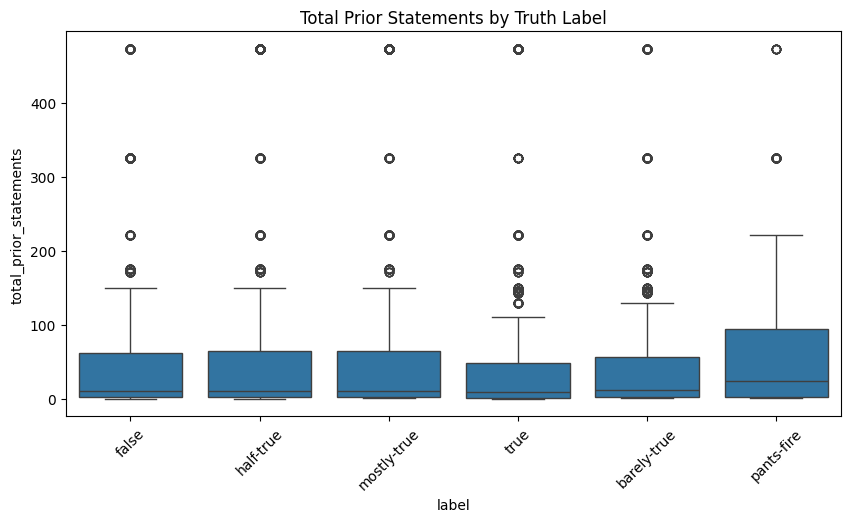

In [68]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="label", y="total_prior_statements")
plt.xticks(rotation=45)
plt.title("Total Prior Statements by Truth Label")
plt.show()

While the distributions largely overlap, statements rated "pants-fire" appear to come more frequently from high-volume speakers, suggesting that repeated public figures may accumulate extreme fact-check ratings over time.

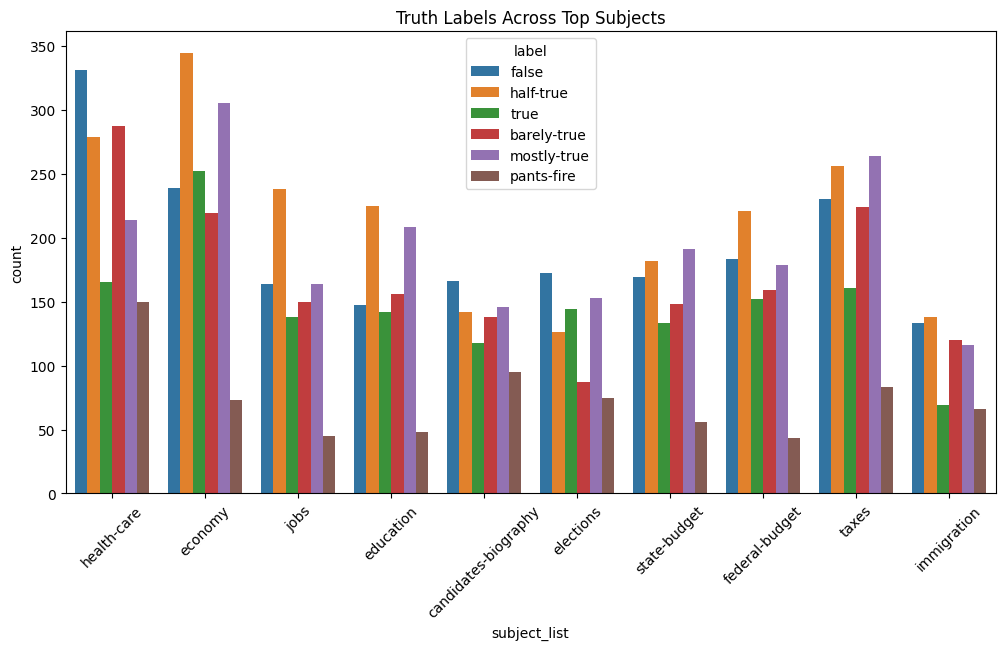

In [69]:
df["subject_list"] = df["subject"].str.split(",")

df_exploded = df.explode("subject_list")

df_exploded["subject_list"] = df_exploded["subject_list"].str.strip()

top_subjects = df_exploded["subject_list"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(
    data=df_exploded[df_exploded["subject_list"].isin(top_subjects)],
    x="subject_list",
    hue="label"
)
plt.xticks(rotation=45)
plt.title("Truth Labels Across Top Subjects")
plt.show()

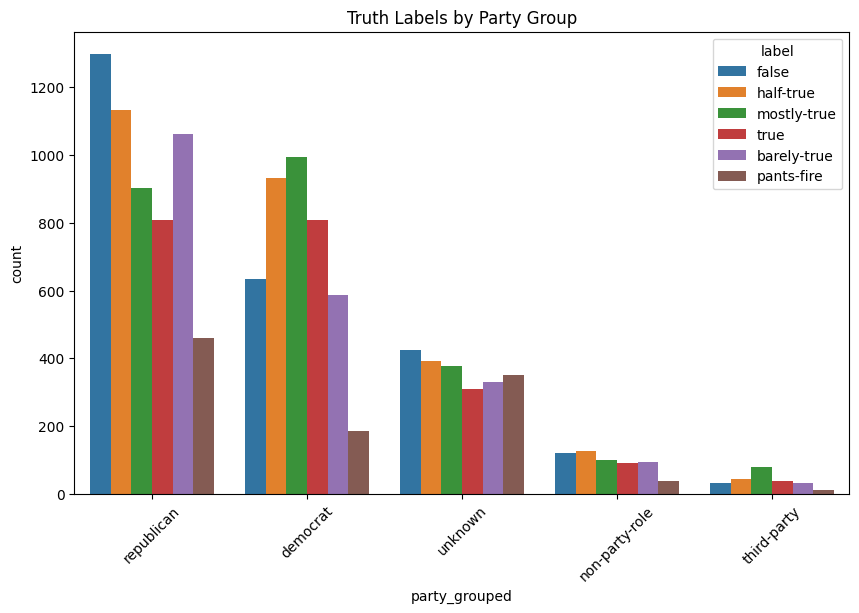

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="party_grouped", hue="label")
plt.xticks(rotation=45)
plt.title("Truth Labels by Party Group")
plt.show()

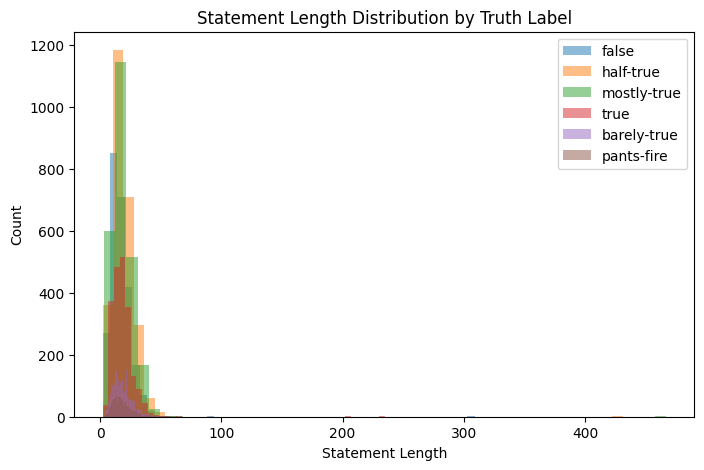

              count       mean        std  min   25%   50%   75%    max
label                                                                  
barely-true  2103.0  18.151213   7.792013  4.0  13.0  17.0  23.0   57.0
false        2507.0  16.872756   9.599448  2.0  11.0  15.0  21.0  309.0
half-true    2627.0  18.958508  11.422151  2.0  13.0  18.0  23.0  431.0
mostly-true  2454.0  18.504482  11.899557  3.0  13.0  17.0  23.0  467.0
pants-fire   1047.0  17.242598   7.484489  3.0  12.0  16.0  22.0   53.0
true         2053.0  18.031174   9.830632  2.0  12.0  16.0  22.0  235.0


In [43]:
plt.figure(figsize=(8,5))

for lbl in df["label"].unique():
    subset = df[df["label"] == lbl]["statement_length"]
    plt.hist(subset, bins=50, alpha=0.5, label=lbl)

plt.legend()
plt.title("Statement Length Distribution by Truth Label")
plt.xlabel("Statement Length")
plt.ylabel("Count")
plt.show()

print(df.groupby("label")["statement_length"].describe())

In [44]:
prior_cols = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "total_prior_statements"
]

print(df.groupby("label")[prior_cols].mean())

             barely_true_counts  false_counts  half_true_counts  \
label                                                             
barely-true           11.788873     12.481693         14.904422   
false                 11.322156     15.367265         14.606786   
half-true             12.265702     13.019794         20.483441   
mostly-true           11.969845     12.428280         19.840668   
pants-fire            10.765043     17.884432         11.152818   
true                  10.777399     11.046274         18.353142   

             mostly_true_counts  pants_on_fire_counts  total_prior_statements  
label                                                                          
barely-true           13.983833              5.353780               58.512601  
false                 13.449501              7.748503               62.444356  
half-true             19.106205              4.531024               69.406167  
mostly-true           20.687857              3.807253          

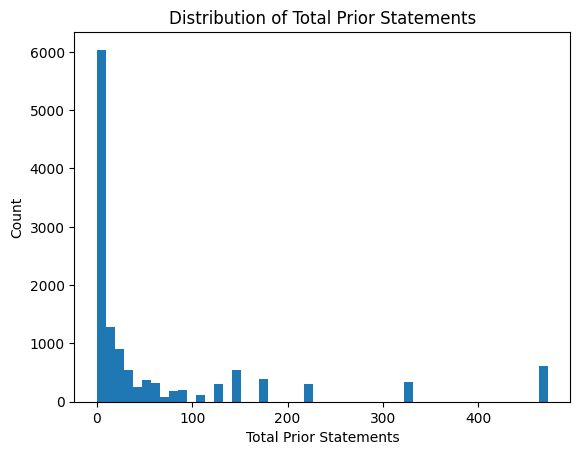

count    12791.000000
mean        64.867876
std        115.749162
min          0.000000
25%          2.000000
50%         11.000000
75%         65.000000
max        473.000000
Name: total_prior_statements, dtype: float64


In [45]:
plt.hist(df["total_prior_statements"], bins=50)
plt.title("Distribution of Total Prior Statements")
plt.xlabel("Total Prior Statements")
plt.ylabel("Count")
plt.show()

print(df["total_prior_statements"].describe())

In [46]:
top_speakers = df["speaker"].value_counts().head(20)

print(top_speakers)

print("\nProportion of dataset from top 20 speakers:")
print(top_speakers.sum() / len(df))

speaker
barack-obama       611
donald-trump       343
hillary-clinton    297
mitt-romney        212
john-mccain        189
scott-walker       183
chain-email        178
rick-perry         173
marco-rubio        153
rick-scott         150
ted-cruz           118
bernie-s           106
chris-christie     104
facebook-posts     100
charlie-crist       90
newt-gingrich       83
blog-posting        81
jeb-bush            79
joe-biden           76
paul-ryan           70
Name: count, dtype: int64

Proportion of dataset from top 20 speakers:
0.26549917911031196


In [47]:
top20 = df["speaker"].value_counts().head(20).index

top_df = df[df["speaker"].isin(top20)]

speaker_truth = pd.crosstab(
    top_df["speaker"],
    top_df["label"],
    normalize="index"
)

print(speaker_truth)

label            barely-true     false  half-true  mostly-true  pants-fire  \
speaker                                                                      
barack-obama        0.114566  0.132570   0.270049     0.266776    0.014730   
bernie-s            0.169811  0.113208   0.198113     0.386792    0.000000   
blog-posting        0.086420  0.234568   0.037037     0.061728    0.543210   
chain-email         0.061798  0.241573   0.044944     0.028090    0.589888   
charlie-crist       0.166667  0.166667   0.244444     0.222222    0.022222   
chris-christie      0.096154  0.173077   0.259615     0.182692    0.076923   
donald-trump        0.183673  0.341108   0.148688     0.107872    0.177843   
facebook-posts      0.140000  0.180000   0.150000     0.110000    0.360000   
hillary-clinton     0.134680  0.107744   0.232323     0.255892    0.023569   
jeb-bush            0.215190  0.063291   0.215190     0.303797    0.025316   
joe-biden           0.144737  0.144737   0.276316     0.210526  

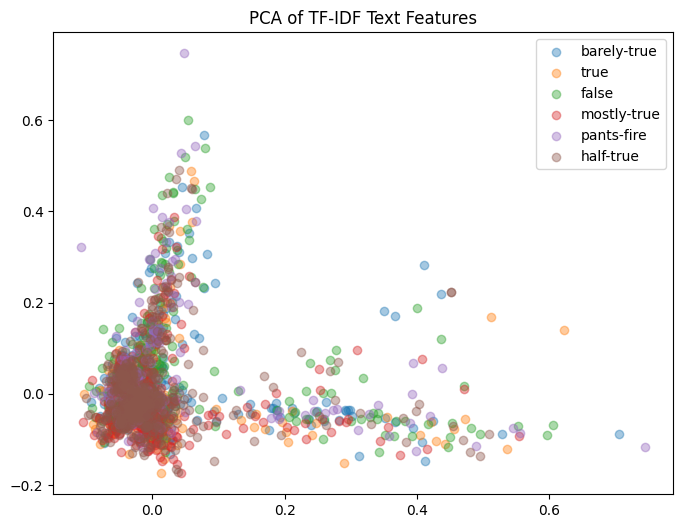

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

sample_df = df.sample(3000, random_state=42)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X_text = vectorizer.fit_transform(sample_df["statement"])

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_text.toarray())

plt.figure(figsize=(8,6))

for lbl in sample_df["label"].unique():
    idx = sample_df["label"] == lbl
    plt.scatter(
        X_reduced[idx, 0],
        X_reduced[idx, 1],
        alpha=0.4,
        label=lbl
    )

plt.legend()
plt.title("PCA of TF-IDF Text Features")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_text)

ari = adjusted_rand_score(sample_df["label"], clusters)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: -0.0014813636313413985


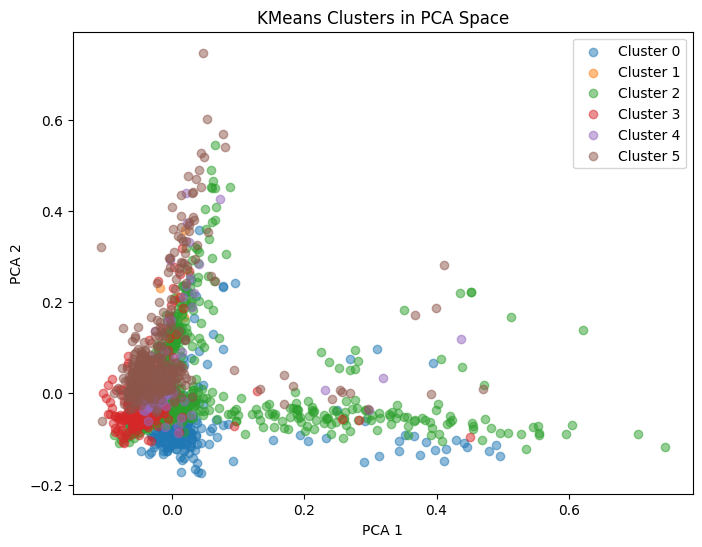

In [50]:
plt.figure(figsize=(8,6))

for c in range(6):
    idx = clusters == c
    plt.scatter(
        X_reduced[idx, 0],
        X_reduced[idx, 1],
        alpha=0.5,
        label=f"Cluster {c}"
    )

plt.legend()
plt.title("KMeans Clusters in PCA Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [51]:
df

,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,statement_length,total_prior_statements
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,11,1.0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,24,2.0
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,19,473.0
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,12,78.0
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,10,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12786,7334.json,half-true,Says his budget provides the highest state fun...,education,rick-scott,Governor,Florida,republican,28.0,23.0,38.0,34.0,7.0,a news conference,13,130.0
12787,9788.json,barely-true,Ive been here almost every day.,"civil-rights,crime,criminal-justice",jay-nixon,Governor,Missouri,democrat,2.0,0.0,0.0,1.0,0.0,"on ABC's ""This Week""",6,3.0
12788,10710.json,barely-true,"In the early 1980s, Sen. Edward Kennedy secret...","bipartisanship,congress,foreign-policy,history",mackubin-thomas-owens,"senior fellow, Foreign Policy Research Institute",Rhode Island,columnist,1.0,0.0,0.0,0.0,0.0,a commentary in The Providence Journal,21,1.0
12789,3186.json,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",john-kasich,"Governor of Ohio as of Jan. 10, 2011",Ohio,republican,9.0,8.0,10.0,18.0,3.0,a news conference,18,48.0


In [72]:
df.to_csv("../data/processed/processed_liar.csv")